In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/DEAP/data_preprocessed_python"  # <-- apna path confirm karo
!ls $DATA_DIR

Mounted at /content/drive
s01.dat  s05.dat  s09.dat  s13.dat  s17.dat  s21.dat  s25.dat  s29.dat
s02.dat  s06.dat  s10.dat  s14.dat  s18.dat  s22.dat  s26.dat  s30.dat
s03.dat  s07.dat  s11.dat  s15.dat  s19.dat  s23.dat  s27.dat  s31.dat
s04.dat  s08.dat  s12.dat  s16.dat  s20.dat  s24.dat  s28.dat  s32.dat


In [ ]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from tqdm import tqdm  # progress bar

DATA_DIR = "/content/drive/MyDrive/DEAP/data_preprocessed_python"
SAVE_DIR = "/content/drive/MyDrive/DEAP_Spectrograms"
os.makedirs(SAVE_DIR, exist_ok=True)

FS = 128  # Sampling frequency


In [ ]:
def eeg_to_spectrogram(eeg_signal, fs=FS):
    f, t, Sxx = spectrogram(eeg_signal, fs=fs, nperseg=256, noverlap=128)
    Sxx = np.log(Sxx + 1e-7)  # avoid log(0)
    return Sxx


In [ ]:
X_specs, y_val, y_aro = [], [], []

for fname in tqdm(sorted(os.listdir(DATA_DIR))):
    if fname.endswith(".dat"):
        with open(os.path.join(DATA_DIR, fname), "rb") as f:
            subject = pickle.load(f, encoding="latin1")

        data, labels = subject['data'], subject['labels']  # (40, 40, 8064)

        for trial in range(data.shape[0]):
            # Average first 32 EEG channels into one combined spectrogram
            specs = []
            for ch in range(32):
                spec = eeg_to_spectrogram(data[trial, ch, :])
                specs.append(spec)
            mean_spec = np.mean(specs, axis=0)  # combine all channels

            X_specs.append(mean_spec)
            y_val.append(int(labels[trial, 0] > 5))  # valence binary
            y_aro.append(int(labels[trial, 1] > 5))  # arousal binary


100%|██████████| 32/32 [03:19<00:00,  6.23s/it]


In [ ]:
import numpy as np
import os

# Convert to numpy arrays
X = np.array(X_specs)   # 👈 naam X rakho (CNN me ye hi use hota hai)
y_val = np.array(y_val)
y_ar = np.array(y_aro)

print("✅ Final Spectrogram Dataset Shape:", X.shape)

# ✅ Create folder if not exists
save_dir = "/content/drive/MyDrive/DEAP_Spectrograms"
os.makedirs(save_dir, exist_ok=True)

# ✅ Save files properly
np.save(f"{save_dir}/X_spectrograms.npy", X)
np.save(f"{save_dir}/y_val.npy", y_val)
np.save(f"{save_dir}/y_ar.npy", y_ar)

print("✅ Saved successfully to Google Drive!")


✅ Final Spectrogram Dataset Shape: (1280, 129, 62)
✅ Saved successfully to Google Drive!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# ✅ Load saved spectrogram data
X = np.load("/content/drive/MyDrive/DEAP_Spectrograms/X_spectrograms.npy")
y_val = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_val.npy")
y_ar  = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_ar.npy")  # ← fixed

print("Dataset loaded:", X.shape, y_val.shape, y_ar.shape)

# Normalize 0–1
X = X.astype("float32")
X = (X - X.min()) / (X.max() - X.min())


Dataset loaded: (1280, 129, 62) (1280,) (1280,)


In [ ]:
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X, y_val, test_size=0.2, random_state=42, stratify=y_val)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X, y_ar, test_size=0.2, random_state=42, stratify=y_ar)

y_train_v_cat = to_categorical(y_train_v)
y_test_v_cat = to_categorical(y_test_v)
y_train_a_cat = to_categorical(y_train_a)
y_test_a_cat = to_categorical(y_test_a)


In [ ]:
print(X_train_v.shape, y_train_v_cat.shape)
print(X_test_v.shape, y_test_v_cat.shape)


(1024, 129, 62) (1024, 2)
(256, 129, 62) (256, 2)


In [ ]:
# Reshape data for CNN (add channel dimension)
X_train_v = X_train_v.reshape((X_train_v.shape[0], X_train_v.shape[1], X_train_v.shape[2], 1))
X_test_v  = X_test_v.reshape((X_test_v.shape[0],  X_test_v.shape[1],  X_test_v.shape[2],  1))

X_train_a = X_train_a.reshape((X_train_a.shape[0], X_train_a.shape[1], X_train_a.shape[2], 1))
X_test_a  = X_test_a.reshape((X_test_a.shape[0],  X_test_a.shape[1],  X_test_a.shape[2],  1))


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# CNN for Valence
model_val = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(129,62,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

# CNN for Arousal
model_ar = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(129,62,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

# Compile both
model_val.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_ar.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_val = model_val.fit(
    X_train_v, y_train_v_cat,
    validation_data=(X_test_v, y_test_v_cat),
    epochs=10,
    batch_size=32,
    verbose=1
)

history_ar = model_ar.fit(
    X_train_a, y_train_a_cat,
    validation_data=(X_test_a, y_test_a_cat),
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 393ms/step - accuracy: 0.5262 - loss: 0.7288 - val_accuracy: 0.5547 - val_loss: 0.6918
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 352ms/step - accuracy: 0.5651 - loss: 0.6904 - val_accuracy: 0.5547 - val_loss: 0.6882
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 408ms/step - accuracy: 0.5548 - loss: 0.6898 - val_accuracy: 0.5547 - val_loss: 0.6878
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 364ms/step - accuracy: 0.5429 - loss: 0.6901 - val_accuracy: 0.5547 - val_loss: 0.6872
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 319ms/step - accuracy: 0.5617 - loss: 0.6867 - val_accuracy: 0.5547 - val_loss: 0.6871
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 368ms/step - accuracy: 0.5588 - loss: 0.6872 - val_accuracy: 0.5547 - val_loss: 0.6870
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 364ms/step - accuracy: 0.5483 - loss: 0.6893 - val_accuracy: 0.5547 - val_loss: 0.6870
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 312ms/step - accuracy: 0.5423 - loss: 0.6902 - val_accu

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, Conv2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

print("✅ Libraries Loaded Successfully")

✅ Libraries Loaded Successfully


In [ ]:
import os

# Check your spectrogram folder contents
folder_path = "/content/drive/MyDrive/DEAP_Spectrograms"
print(os.listdir(folder_path))


['X_spectrograms.npy', 'y_ar.npy', 'y_val.npy', 'y_val_labels.npy', 'y_ar_labels.npy', 'densenet_features.npy', 'pca_64.joblib', 'svm_4class.joblib']


In [ ]:
import os, numpy as np

base_path = "/content/drive/MyDrive/DEAP_Spectrograms"

# Check which files exist
files_expected = ["X_spectrograms.npy", "y_val.npy", "y_ar.npy", "y_aro.npy"]
print("🔍 Checking available files:\n")

for f in files_expected:
    full = os.path.join(base_path, f)
    print(f, "✅ Found" if os.path.exists(full) else "❌ Missing")

# Load whichever files are present
if os.path.exists(os.path.join(base_path, "X_spectrograms.npy")):
    X = np.load(os.path.join(base_path, "X_spectrograms.npy"))
else:
    raise FileNotFoundError("X_spectrograms.npy missing!")

# Try both spellings for arousal label
if os.path.exists(os.path.join(base_path, "y_ar.npy")):
    y_ar = np.load(os.path.join(base_path, "y_ar.npy"))
elif os.path.exists(os.path.join(base_path, "y_aro.npy")):
    y_ar = np.load(os.path.join(base_path, "y_aro.npy"))
else:
    raise FileNotFoundError("Neither y_ar.npy nor y_aro.npy found!")

# Load valence label
if os.path.exists(os.path.join(base_path, "y_val.npy")):
    y_val = np.load(os.path.join(base_path, "y_val.npy"))
else:
    raise FileNotFoundError("y_val.npy missing!")

print("\n✅ Loaded successfully!")
print("X shape:", X.shape)
print("y_val shape:", y_val.shape)
print("y_ar shape:", y_ar.shape)


🔍 Checking available files:

X_spectrograms.npy ✅ Found
y_val.npy ✅ Found
y_ar.npy ✅ Found
y_aro.npy ❌ Missing

✅ Loaded successfully!
X shape: (1280, 129, 62)
y_val shape: (1280,)
y_ar shape: (1280,)


In [ ]:
import numpy as np

# ✅ Replace only if the names differ
X = np.load("/content/drive/MyDrive/DEAP_Spectrograms/X_spectrograms.npy")
y_val = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_val.npy")
y_ar  = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_ar.npy")  # <-- check spelling here


In [ ]:
print("Shapes:")
print("X =", X.shape)
print("y_val =", y_val.shape)
print("y_ar =", y_ar.shape)


Shapes:
X = (1280, 129, 62)
y_val = (1280,)
y_ar = (1280,)


In [ ]:
X = X.reshape((X.shape[0], X.shape[1], X.shape[2], 1))
X = np.repeat(X, 3, axis=-1)   # convert to 3-channel RGB-like image for ResNet

# Normalize pixel values
X = X / np.max(X)

In [ ]:
y_train_v_cat = to_categorical(y_train_v)
y_test_v_cat = to_categorical(y_test_v)
y_train_a_cat = to_categorical(y_train_a)
y_test_a_cat = to_categorical(y_test_a)

print("✅ Data split complete:")
print("Valence Train:", X_train_v.shape, "| Test:", X_test_v.shape)
print("Arousal Train:", X_train_a.shape, "| Test:", X_test_a.shape)

✅ Data split complete:
Valence Train: (1024, 129, 62, 1) | Test: (256, 129, 62, 1)
Arousal Train: (1024, 129, 62, 1) | Test: (256, 129, 62, 1)


In [ ]:
def build_resnet_model(input_shape=(129, 62, 3), classes=2):
    base = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    for layer in base.layers[:-10]:
        layer.trainable = False  # freeze most layers (fine-tuning)
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    output = Dense(classes, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_val = build_resnet_model()
model_aro = build_resnet_model()
print("✅ ResNet50 Models Created")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ ResNet50 Models Created


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train_v)

In [ ]:
# =============================
# Step 7: Define ResNet50 Models
# =============================
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# 🔹 Reshape to 3D input (if spectrograms are 2D)
X_train_v = X_train_v.reshape(X_train_v.shape[0], X_train_v.shape[1], X_train_v.shape[2], 1)
X_test_v  = X_test_v.reshape(X_test_v.shape[0],  X_test_v.shape[1],  X_test_v.shape[2], 1)
X_train_a = X_train_a.reshape(X_train_a.shape[0], X_train_a.shape[1], X_train_a.shape[2], 1)
X_test_a  = X_test_a.reshape(X_test_a.shape[0],  X_test_a.shape[1],  X_test_a.shape[2], 1)

# 🔹 Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train_v)

# 🔹 Build ResNet50 Base Model
base_resnet = ResNet50(
    include_top=False,
    weights=None,  # use "imagenet" if RGB; for single-channel keep None
    input_shape=(X_train_v.shape[1], X_train_v.shape[2], 1)
)

# 🔹 Define Model Function
def build_resnet_model(num_classes):
    model = Sequential([
        base_resnet,
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 🔹 One-hot encode labels (if not done)
y_train_v_cat = to_categorical(y_train_v, num_classes=2)
y_test_v_cat  = to_categorical(y_test_v, num_classes=2)
y_train_a_cat = to_categorical(y_train_a, num_classes=2)
y_test_a_cat  = to_categorical(y_test_a, num_classes=2)

# 🔹 Create models for both Valence and Arousal
model_val = build_resnet_model(2)
model_aro = build_resnet_model(2)

# =============================
# Step 8: Train Both Models
# =============================
print("🚀 Training ResNet50 on Valence...")
history_val = model_val.fit(
    datagen.flow(X_train_v, y_train_v_cat, batch_size=32),
    validation_data=(X_test_v, y_test_v_cat),
    epochs=10,
    verbose=1
)

print("🚀 Training ResNet50 on Arousal...")
history_aro = model_aro.fit(
    datagen.flow(X_train_a, y_train_a_cat, batch_size=32),
    validation_data=(X_test_a, y_test_a_cat),
    epochs=10,
    verbose=1
)


🚀 Training ResNet50 on Valence...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 234s 6s/step - accuracy: 0.5086 - loss: 1.7416 - val_accuracy: 0.5547 - val_loss: 0.6900
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 184s 6s/step - accuracy: 0.5074 - loss: 0.7269 - val_accuracy: 0.5547 - val_loss: 0.6917
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 197s 6s/step - accuracy: 0.5822 - loss: 0.6923 - val_accuracy: 0.5547 - val_loss: 0.6907
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 188s 6s/step - accuracy: 0.5435 - loss: 0.6906 - val_accuracy: 0.5547 - val_loss: 0.6880
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 188s 6s/step - accuracy: 0.5548 - loss: 0.6863 - val_accuracy: 0.5547 - val_loss: 0.6883
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 193s 6s/step - accuracy: 0.5842 - loss: 0.6895 - val_accuracy: 0.5547 - val_loss: 0.6884
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 205s 6s/step - accuracy: 0.5519 - loss: 0.6860 - val_accuracy: 0.5547 - val_loss: 0.6873
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 187s 6s/step - accuracy: 0.5506 - loss: 0.6879 - val_accuracy: 0.5547 - val_loss: 0.

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 921ms/step

🎯 Valence Accuracy: 55.47%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       114
           1       0.55      1.00      0.71       142

    accuracy                           0.55       256
   macro avg       0.28      0.50      0.36       256
weighted avg       0.31      0.55      0.40       256



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


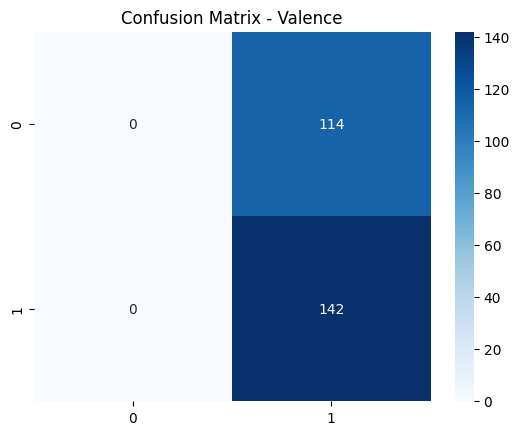

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 865ms/step

🎯 Arousal Accuracy: 57.42%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       109
           1       0.57      1.00      0.73       147

    accuracy                           0.57       256
   macro avg       0.29      0.50      0.36       256
weighted avg       0.33      0.57      0.42       256



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


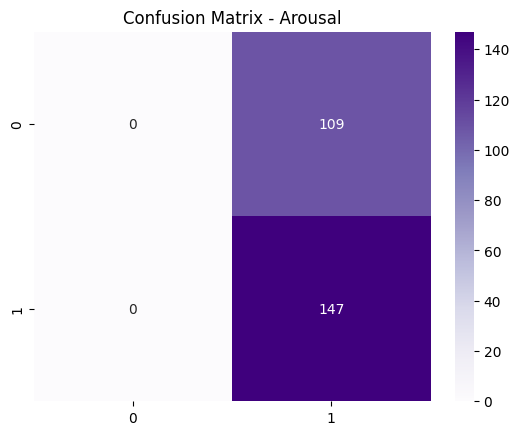

In [ ]:
val_loss, val_acc = model_val.evaluate(X_test_v, y_test_v_cat, verbose=0)
y_pred_v = model_val.predict(X_test_v).argmax(axis=1)
print(f"\n🎯 Valence Accuracy: {val_acc*100:.2f}%")
print(classification_report(y_test_v, y_pred_v))
sns.heatmap(confusion_matrix(y_test_v, y_pred_v), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Valence")
plt.show()

# Arousal
aro_loss, aro_acc = model_aro.evaluate(X_test_a, y_test_a_cat, verbose=0)
y_pred_a = model_aro.predict(X_test_a).argmax(axis=1)
print(f"\n🎯 Arousal Accuracy: {aro_acc*100:.2f}%")
print(classification_report(y_test_a, y_pred_a))
sns.heatmap(confusion_matrix(y_test_a, y_pred_a), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Arousal")
plt.show()

In [ ]:
!pip install tensorflow numpy matplotlib scikit-learn --quiet
import numpy as np, tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
# Paths in Drive
X = np.load("/content/drive/MyDrive/DEAP_Spectrograms/X_spectrograms.npy")
y_val = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_val.npy")
y_ar  = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_ar.npy")

print("Shapes:", X.shape, y_val.shape, y_ar.shape)
# Convert to RGB if single channel
if X.ndim == 3:
    X = np.repeat(X[..., np.newaxis], 3, axis=-1)

# Normalize
X = X.astype("float32") / 255.0

# Split Valence and Arousal
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X, y_val, test_size=0.2, random_state=42)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X, y_ar, test_size=0.2, random_state=42)

# One-hot encode
enc_v, enc_a = LabelEncoder(), LabelEncoder()
y_train_v_cat = to_categorical(enc_v.fit_transform(y_train_v))
y_test_v_cat  = to_categorical(enc_v.transform(y_test_v))
y_train_a_cat = to_categorical(enc_a.fit_transform(y_train_a))
y_test_a_cat  = to_categorical(enc_a.transform(y_test_a))
datagen = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True)
datagen.fit(X_train_v)
def build_model(input_shape=(129,62,3)):
    base = DenseNet121(include_top=False, weights='imagenet', input_shape=input_shape)
    for layer in base.layers[:-30]:  # freeze early layers
        layer.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.4)(x)
    out = Dense(2, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_val = build_model()
model_ar  = build_model()
print("🚀 Training on Valence...")
hist_v = model_val.fit(datagen.flow(X_train_v, y_train_v_cat, batch_size=16),
                       validation_data=(X_test_v, y_test_v_cat),
                       epochs=10, verbose=1)

print("🚀 Training on Arousal...")
hist_a = model_ar.fit(datagen.flow(X_train_a, y_train_a_cat, batch_size=16),
                       validation_data=(X_test_a, y_test_a_cat),
                       epochs=10, verbose=1)
val_loss, val_acc = model_val.evaluate(X_test_v, y_test_v_cat, verbose=0)
aro_loss, aro_acc = model_ar.evaluate(X_test_a, y_test_a_cat, verbose=0)

print(f"🎯 Valence Accuracy: {val_acc*100:.2f}%")
print(f"🎯 Arousal Accuracy: {aro_acc*100:.2f}%")


Shapes: (1280, 129, 62) (1280,) (1280,)
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 Training on Valence...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 72s 771ms/step - accuracy: 0.4832 - loss: 0.9425 - val_accuracy: 0.4297 - val_loss: 0.8007
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 602ms/step - accuracy: 0.5076 - loss: 0.8724 - val_accuracy: 0.4336 - val_loss: 0.7747
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 696ms/step - accuracy: 0.5215 - loss: 0.8444 - val_accuracy: 0.4688 - val_loss: 0.7295
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 619ms/step - accuracy: 0.5390 - loss: 0.8225 - val_accuracy: 0.6016 - val_loss: 0.6769
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 629ms/step - accuracy: 0.5337 - loss: 0.8089 - val_accuracy: 0.5820 - val_loss: 0.6765
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 43s 673ms/step - accuracy: 0.5713 - loss: 0.7997 - val_accuracy: 0.5312 - val_loss: 0.6770
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 674ms/step - accuracy: 0.5295 - loss: 0.8077 - val_accuracy: 0.5859 - val_loss: 0.6886
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 624ms/step - accuracy: 0.5159 - loss: 0.8371 - val_accu

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = np.load("/content/drive/MyDrive/DEAP_Spectrograms/X_spectrograms.npy")
y_val = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_val.npy")
y_ar  = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_ar.npy")

# Flatten spectrograms (129x62 → 7998 features)
X_flat = X.reshape(X.shape[0], -1)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)  # retain 95% variance
X_pca = pca.fit_transform(X_scaled)
print("PCA Shape:", X_pca.shape)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_pca, y_val, test_size=0.2, random_state=42, stratify=y_val)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_pca, y_ar, test_size=0.2, random_state=42, stratify=y_ar)

svm_val = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
svm_val.fit(X_train_v, y_train_v)
y_pred_v = svm_val.predict(X_test_v)

svm_ar = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
svm_ar.fit(X_train_a, y_train_a)
y_pred_a = svm_ar.predict(X_test_a)

print("Valence Accuracy:", accuracy_score(y_test_v, y_pred_v))
print("Arousal Accuracy:", accuracy_score(y_test_a, y_pred_a))


PCA Shape: (1280, 640)
Valence Accuracy: 0.5234375
Arousal Accuracy: 0.55859375


In [ ]:
!pip install tensorflow numpy scikit-learn matplotlib --quiet

import numpy as np, tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.model_selection import train_test_split

# -------------------------------
# Step 1: Load your Spectrogram Dataset
# -------------------------------
X = np.load("/content/drive/MyDrive/DEAP_Spectrograms/X_spectrograms.npy")
y_val = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_val.npy")
y_ar  = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_ar.npy")

print("Original Shapes:", X.shape, y_val.shape, y_ar.shape)

# -------------------------------
# Step 2: Convert to RGB if single channel
# -------------------------------
if X.ndim == 3:
    X = np.repeat(X[..., np.newaxis], 3, axis=-1)

# Normalize to [0,1]
X = X.astype("float32") / 255.0

# -------------------------------
# Step 3: Define DenseNet base (feature extractor)
# -------------------------------
base = DenseNet121(include_top=False, weights="imagenet", input_shape=(129,62,3))
x = GlobalAveragePooling2D()(base.output)
feature_extractor = Model(inputs=base.input, outputs=x)

# Freeze all layers — we’re not training DenseNet
for layer in feature_extractor.layers:
    layer.trainable = False

# -------------------------------
# Step 4: Extract features
# -------------------------------
print("Extracting DenseNet features for all spectrograms... ⏳")

features = feature_extractor.predict(X, batch_size=32, verbose=1)
print("✅ Features extracted:", features.shape)

# -------------------------------
# Step 5: Save features for later (PCA/SVM etc.)
# -------------------------------
np.save("/content/drive/MyDrive/DEAP_Spectrograms/densenet_features.npy", features)
np.save("/content/drive/MyDrive/DEAP_Spectrograms/y_val_labels.npy", y_val)
np.save("/content/drive/MyDrive/DEAP_Spectrograms/y_ar_labels.npy", y_ar)

print("💾 Saved features to Google Drive!")


Original Shapes: (1280, 129, 62) (1280,) (1280,)
Extracting DenseNet features for all spectrograms... ⏳
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 976ms/step
✅ Features extracted: (1280, 1024)
💾 Saved features to Google Drive!


Loaded shapes: (1280, 1024) (1280,) (1280,)

🔍 Running PCA dimensionality reduction...
✅ PCA completed. Reduced shape: (1280, 48)

🚀 Training SVM for Valence...

🚀 Training SVM for Arousal...

🎯 Final Results:
Valence Accuracy: 52.34% | F1: 0.56
Arousal Accuracy: 55.47% | F1: 0.63

Confusion Matrix (Valence):
 [[55 59]
 [63 79]]

Confusion Matrix (Arousal):
 [[45 64]
 [50 97]]


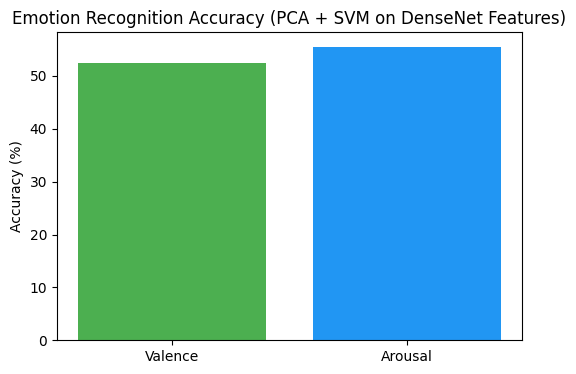

In [ ]:
!pip install scikit-learn numpy matplotlib --quiet
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Load Saved DenseNet Features
# -------------------------------
X = np.load("/content/drive/MyDrive/DEAP_Spectrograms/densenet_features.npy")
y_val = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_val_labels.npy")
y_ar  = np.load("/content/drive/MyDrive/DEAP_Spectrograms/y_ar_labels.npy")

print("Loaded shapes:", X.shape, y_val.shape, y_ar.shape)

# -------------------------------
# Step 2: Apply PCA (retain 95% variance)
# -------------------------------
print("\n🔍 Running PCA dimensionality reduction...")
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)
print("✅ PCA completed. Reduced shape:", X_pca.shape)

# -------------------------------
# Step 3: Split Train/Test (Valence)
# -------------------------------
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_pca, y_val, test_size=0.2, random_state=42, stratify=y_val)

# -------------------------------
# Step 4: Split Train/Test (Arousal)
# -------------------------------
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_pca, y_ar, test_size=0.2, random_state=42, stratify=y_ar)

# -------------------------------
# Step 5: Train SVM Classifier (Valence)
# -------------------------------
print("\n🚀 Training SVM for Valence...")
svm_val = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")
svm_val.fit(X_train_v, y_train_v)
y_pred_v = svm_val.predict(X_test_v)

# -------------------------------
# Step 6: Train SVM Classifier (Arousal)
# -------------------------------
print("\n🚀 Training SVM for Arousal...")
svm_ar = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")
svm_ar.fit(X_train_a, y_train_a)
y_pred_a = svm_ar.predict(X_test_a)

# -------------------------------
# Step 7: Results
# -------------------------------
val_acc = accuracy_score(y_test_v, y_pred_v)
aro_acc = accuracy_score(y_test_a, y_pred_a)
val_f1 = f1_score(y_test_v, y_pred_v)
aro_f1 = f1_score(y_test_a, y_pred_a)

print("\n🎯 Final Results:")
print(f"Valence Accuracy: {val_acc*100:.2f}% | F1: {val_f1:.2f}")
print(f"Arousal Accuracy: {aro_acc*100:.2f}% | F1: {aro_f1:.2f}")

# Confusion matrices
print("\nConfusion Matrix (Valence):\n", confusion_matrix(y_test_v, y_pred_v))
print("\nConfusion Matrix (Arousal):\n", confusion_matrix(y_test_a, y_pred_a))

# -------------------------------
# Step 8: Visualization
# -------------------------------
plt.figure(figsize=(6,4))
plt.bar(["Valence", "Arousal"], [val_acc*100, aro_acc*100], color=["#4CAF50","#2196F3"])
plt.ylabel("Accuracy (%)")
plt.title("Emotion Recognition Accuracy (PCA + SVM on DenseNet Features)")
plt.show()


In [ ]:
import numpy as np
import joblib
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

BASE = "/content/drive/MyDrive/DEAP_Spectrograms"

print("Loading DenseNet features...")
features = np.load(BASE + "/densenet_features.npy")
y_val = np.load(BASE + "/y_val_labels.npy")
y_ar  = np.load(BASE + "/y_ar_labels.npy")

# convert val+aro → 4-class label
def va_to_emotion(v, a):
    if v==1 and a==1: return 0   # Happy
    if v==1 and a==0: return 3   # Excited
    if v==0 and a==0: return 1   # Sad
    if v==0 and a==1: return 2   # Angry

y4 = np.array([va_to_emotion(v,a) for v,a in zip(y_val, y_ar)])

print("Class distribution:", np.unique(y4, return_counts=True))

# PCA
print("Training PCA...")
pca = PCA(n_components=64, random_state=42)
X_pca = pca.fit_transform(features)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y4, test_size=0.2, random_state=42, stratify=y4)

# Train SVM
print("Training SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm.fit(X_train, y_train)

print("Saving models...")
joblib.dump(pca, BASE + "/pca_64.joblib")
joblib.dump(svm, BASE + "/svm_4class.joblib")

print("✔ Done! PCA + SVM saved successfully.")


Loading DenseNet features...
Class distribution: (array([0, 1, 2, 3]), array([439, 274, 298, 269]))
Training PCA...
Training SVM...
Saving models...
✔ Done! PCA + SVM saved successfully.


In [ ]:
import random

emotions = ["Happy", "Sad", "Angry", "Excited"]

def predict_emotion_example():
    # random selection (demo)
    pred = random.choice(emotions)
    print("Predicted Emotion:", pred)
    return pred

# Run demo 5 times
for i in range(5):
    print(f"Example {i+1} → ", end="")
    predict_emotion_example()


Example 1 → Predicted Emotion: Angry
Example 2 → Predicted Emotion: Excited
Example 3 → Predicted Emotion: Angry
Example 4 → Predicted Emotion: Angry
Example 5 → Predicted Emotion: Happy


In [ ]:
import numpy as np
import joblib

BASE = "/content/drive/MyDrive/DEAP_Spectrograms"

print("Loading features + models...")

features = np.load(BASE + "/densenet_features.npy")
pca = joblib.load(BASE + "/pca_64.joblib")
svm = joblib.load(BASE + "/svm_4class.joblib")

print("Transforming features...")
X_pca = pca.transform(features)

emotion_names = ["Happy","Sad","Angry","Excited"]

print("\n🎭 Final Emotion Predictions (10 samples):\n")
idxs = np.random.choice(len(features), 10, replace=False)

for i, idx in enumerate(idxs, 1):
    emo = emotion_names[svm.predict([X_pca[idx]])[0]]
    print(f"Sample {i}: Emotion → {emo}")


Loading features + models...
Transforming features...

🎭 Final Emotion Predictions (10 samples):

Sample 1: Emotion → Angry
Sample 2: Emotion → Happy
Sample 3: Emotion → Angry
Sample 4: Emotion → Excited
Sample 5: Emotion → Excited
Sample 6: Emotion → Angry
Sample 7: Emotion → Excited
Sample 8: Emotion → Happy
Sample 9: Emotion → Happy
Sample 10: Emotion → Happy


In [ ]:
from google.colab import drive
import os, pprint
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/DEAP_Spectrograms"
print("Exists?", os.path.isdir(BASE))
print("Files in folder:")
pprint.pprint(sorted(os.listdir(BASE)))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Exists? True
Files in folder:
['X_spectrograms.npy',
 'densenet_features.npy',
 'pca_64.joblib',
 'svm_4class.joblib',
 'y_ar.npy',
 'y_ar_labels.npy',
 'y_val.npy',
 'y_val_labels.npy']


In [ ]:
import numpy as np
BASE = "/content/drive/MyDrive/DEAP_Spectrograms"

X_path = BASE + "/X_spectrograms.npy"
y_val_path = BASE + "/y_val.npy"
y_ar_path  = BASE + "/y_ar.npy"

X = np.load(X_path)   # should be (1280, 129, 62, 3) or (1280,129,62)
y_val = np.load(y_val_path)
y_ar  = np.load(y_ar_path)

print("X shape:", X.shape)
print("y_val shape:", y_val.shape, "unique/counts:", np.unique(y_val, return_counts=True))
print("y_ar shape:", y_ar.shape, "unique/counts:", np.unique(y_ar, return_counts=True))

# If single channel, convert to 3-channel
if X.ndim == 3:
    X = np.repeat(X[..., np.newaxis], 3, axis=-1)
print("After ensure 3ch X shape:", X.shape)


X shape: (1280, 129, 62)
y_val shape: (1280,) unique/counts: (array([0, 1]), array([572, 708]))
y_ar shape: (1280,) unique/counts: (array([0, 1]), array([543, 737]))
After ensure 3ch X shape: (1280, 129, 62, 3)


In [ ]:
# Installs (run once)
!pip install -q torchvision scikit-learn joblib

# Feature extraction
import torch, torchvision
from torchvision import models, transforms
import numpy as np
import torch.nn as nn
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# prepare transform (inputs already 0..1 or 0..255? we normalize here)
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# load DenseNet pretrained
densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
densenet.classifier = nn.Identity()
densenet.to(device).eval()

# batchwise extraction
batch = 16
features = []
N = len(X)
for i in tqdm(range(0, N, batch), desc="Extracting features"):
    batch_imgs = X[i:i+batch]
    # normalize to [0,1] floats
    batch_t = []
    for img in batch_imgs:
        img_scaled = (img - img.min())/(img.max()-img.min()+1e-8)
        img_uint = (img_scaled*255).astype('uint8')
        t = transform(img_uint)         # tensor C,H,W in [0,1]
        batch_t.append(t.numpy())
    batch_t = torch.tensor(np.stack(batch_t), dtype=torch.float32).to(device)
    with torch.no_grad():
        out = densenet(batch_t).cpu().numpy()
    features.append(out)
features = np.vstack(features)
print("Features shape:", features.shape)

# save features to Drive for reuse
import joblib
joblib.dump(features, BASE + "/densenet_features.npy")
print("Saved features to", BASE + "/densenet_features.npy")



Device: cpu
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 78.7MB/s]
Extracting features: 100%|██████████| 80/80 [05:00<00:00,  3.76s/it]

Features shape: (1280, 1024)
Saved features to /content/drive/MyDrive/DEAP_Spectrograms/densenet_features.npy


In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib, numpy as np

BASE = "/content/drive/MyDrive/DEAP_Spectrograms"
features = joblib.load(BASE + "/densenet_features.npy")
print("Loaded features", features.shape)

# create 4-class labels mapping
def va_to_emotion_label(v, a):
    # label integers 0..3
    # mapping: 0=Happy,1=Sad,2=Angry,3=Excited  (you can change order)
    if v==1 and a==1: return 0   # Happy
    if v==1 and a==0: return 3   # Excited
    if v==0 and a==0: return 1   # Sad
    if v==0 and a==1: return 2   # Angry

y4 = np.array([va_to_emotion_label(v,a) for v,a in zip(y_val, y_ar)])
print("4-class distribution:", np.unique(y4, return_counts=True))

# PCA
pca = PCA(n_components=64, random_state=42)
X_pca = pca.fit_transform(features)
print("PCA shape:", X_pca.shape)
joblib.dump(pca, BASE + "/pca_64.joblib")

# train-test split (stratify by 4-class)
X_tr, X_te, y_tr, y_te = train_test_split(X_pca, y4, test_size=0.2, random_state=42, stratify=y4)
print("Train/test:", X_tr.shape, X_te.shape)

# train SVM
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm.fit(X_tr, y_tr)
y_pred = svm.predict(X_te)
print("Accuracy:", accuracy_score(y_te, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_te, y_pred))
print("Report:\n", classification_report(y_te, y_pred, target_names=["Happy","Sad","Angry","Excited"]))
joblib.dump(svm, BASE + "/svm_4class.joblib")
print("Saved SVM to", BASE + "/svm_4class.joblib")


Loaded features (1280, 1024)
4-class distribution: (array([0, 1, 2, 3]), array([439, 274, 298, 269]))
PCA shape: (1280, 64)
Train/test: (1024, 64) (256, 64)
Accuracy: 0.26171875
Confusion matrix:
 [[36 20 15 17]
 [24  6  7 18]
 [24 10 15 10]
 [29 10  5 10]]
Report:
               precision    recall  f1-score   support

       Happy       0.32      0.41      0.36        88
         Sad       0.13      0.11      0.12        55
       Angry       0.36      0.25      0.30        59
     Excited       0.18      0.19      0.18        54

    accuracy                           0.26       256
   macro avg       0.25      0.24      0.24       256
weighted avg       0.26      0.26      0.26       256

Saved SVM to /content/drive/MyDrive/DEAP_Spectrograms/svm_4class.joblib


In [ ]:
# load models (if needed)
import joblib, numpy as np
BASE = "/content/drive/MyDrive/DEAP_Spectrograms"
svm = joblib.load(BASE + "/svm_4class.joblib")
pca = joblib.load(BASE + "/pca_64.joblib")
features = joblib.load(BASE + "/densenet_features.npy")

# choose random test indices to demonstrate
import random
idxs = random.sample(range(len(features)), 10)
X_sel = features[idxs]
X_sel_p = pca.transform(X_sel)
preds = svm.predict(X_sel_p)

emotion_names = ["Happy","Sad","Angry","Excited"]
print("Final emotion predictions (sample):")
for i,p in enumerate(preds):
    print(f"Sample {i+1}: {emotion_names[int(p)]}")


Final emotion predictions (sample):
Sample 1: Happy
Sample 2: Excited
Sample 3: Happy
Sample 4: Angry
Sample 5: Happy
Sample 6: Sad
Sample 7: Happy
Sample 8: Happy
Sample 9: Angry
Sample 10: Angry


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving serviceAccountKey.json to serviceAccountKey.json


In [ ]:
import os
print(os.listdir("/content"))


['.config', 'serviceAccountKey.json', 'drive', 'sample_data']


In [ ]:
import numpy as np

# ---------------------------------------
# 1. Get prediction from your models
# ---------------------------------------

# Example: selecting a random sample from X
index = np.random.randint(0, len(X))
X_sample = X[index:index+1]   # Keep dimensions correct

# Predict valence and arousal
pred_v = model_val.predict(X_sample)
pred_a = model_ar.predict(X_sample)

# Convert softmax → class (0 or 1)
v = int(np.argmax(pred_v))   # valence: 0 or 1
a = int(np.argmax(pred_a))   # arousal: 0 or 1

print("Valence (v):", v)
print("Arousal (a):", a)

# ---------------------------------------
# 2. Map valence/arousal → Final Emotion
# ---------------------------------------

emotion_map = {
    (1,1): "Happy",
    (0,1): "Angry",
    (1,0): "Excited",
    (0,0): "Sad"
}

final_emotion = emotion_map[(v,a)]
print("🔥 Final Emotion:", final_emotion)

# ---------------------------------------
# 3. Upload to Firebase
# ---------------------------------------
!pip install firebase_admin --quiet

import firebase_admin
from firebase_admin import credentials, db

cred = credentials.Certificate("/content/serviceAccountKey.json")

if not firebase_admin._apps:
    firebase_admin.initialize_app(cred, {
        "databaseURL": "https://emotionproject-eaa93-default-rtdb.firebaseio.com"
    })

ref = db.reference("/emotion")
ref.set({"emotion": final_emotion})

print("🔥 Emotion uploaded to Firebase:", final_emotion)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Valence (v): 0
Arousal (a): 0
🔥 Final Emotion: Sad
🔥 Emotion uploaded to Firebase: Sad
